# Lab 1.2 - Naive Bayes Pt 2

## 1.1 Instructions

* Run all the code cells in chronological order.
* Put your names and student numbers in the indicated cell in the exact indicated format.
* You cannot use additional libraries to the ones imported already for you.
* Your answers must be placed in the indicated answer code cells and must follow the requested format exactly.
* Code cells containing the comment `# STUDENT ANSWER` are answer code cells.
* Do not delete the answer code cells and recreate them as they have custom metadata used by the automarker. If you accidentally delete one, you must redownload the notebook.
* **Execution Order**: Students must run all prior cells in chronological order. Specific cell dependencies will be highlighted for each task.
* **Determinism Constraint**: Students must not alter any `np.random.seed()` calls. Every call to a random function within this lab is immediately preceded by a seed to ensure identical outputs across multiple executions.

### 1.1.1 Public Test Cases

The 'public test cases' are used for you to check your answers. Hidden test cases using different dataset values will be used to calculate your mark.

In [ ]:
# STUDENT DETAILS
student_names = ["Mutsawashe Njowa"] # List of strings containing student names
student_nos = ["2651487"] # List of strings containing student nos

assert len(student_names) == len(student_nos), "student_names not of same length as student_nos"

## 1.2 Learning Objectives

By completing this lab, you will be able to:

* **Visualise and Analyse Data:** Use data visualisation techniques to inspect feature distributions and evaluate whether foundational assumptions (such as normality and conditional independence) hold true for a given dataset.
* **Implement Mixture Models:** Construct a deterministic Gaussian Mixture Model (GMM) to accurately represent continuous features that exhibit bimodal or multimodal characteristics, overcoming the limitations of a single Gaussian distribution.
* **Prevent Numerical Underflow:** Apply logarithmic transformations to compute unnormalised log-posterior probabilities, a crucial technique for preventing underflow when multiplying many small continuous probability values.
* **Evaluate Model Robustness:** Assess the real-world performance of a Naïve Bayes classifier and understand why it often remains a highly effective tool despite its core independence assumption being demonstrably violated.

In [2]:
# Install required packages if running locally
!pip install numpy pandas matplotlib seaborn

## 1.3 Imports

You are not allowed to import additional libraries to the ones specified below.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

## 2. Section 1: Data Preparation and Visual Analysis

In this section, we load the Palmer Penguins dataset. We will predict the sex of the penguin (0 = Female, 1 = Male) using four continuous features.

### 2.0.1 Data Loading

*Requires: Cell 1.3*

In [4]:
# DO NOT MODIFY
# Load dataset and drop missing values
df = sns.load_dataset("penguins").dropna()

# Extract features and target
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[features].to_numpy()
y = (df['sex'] == 'Male').astype(int).to_numpy()

np.random.seed(42)
indices = np.random.permutation(len(X))
split_idx = int(0.8 * len(X))

X_train, y_train = X[indices[:split_idx]], y[indices[:split_idx]]
X_test, y_test = X[indices[split_idx:]], y[indices[split_idx:]]

### 2.1 Question 1: Visualisation

*Requires: Cell 2.0.1*

Visualise the dataset to understand the underlying distributions. Use seaborn's `pairplot` to plot the dataframe `df`, grouping the data by the `sex` column.

c:\Users\tcbos\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


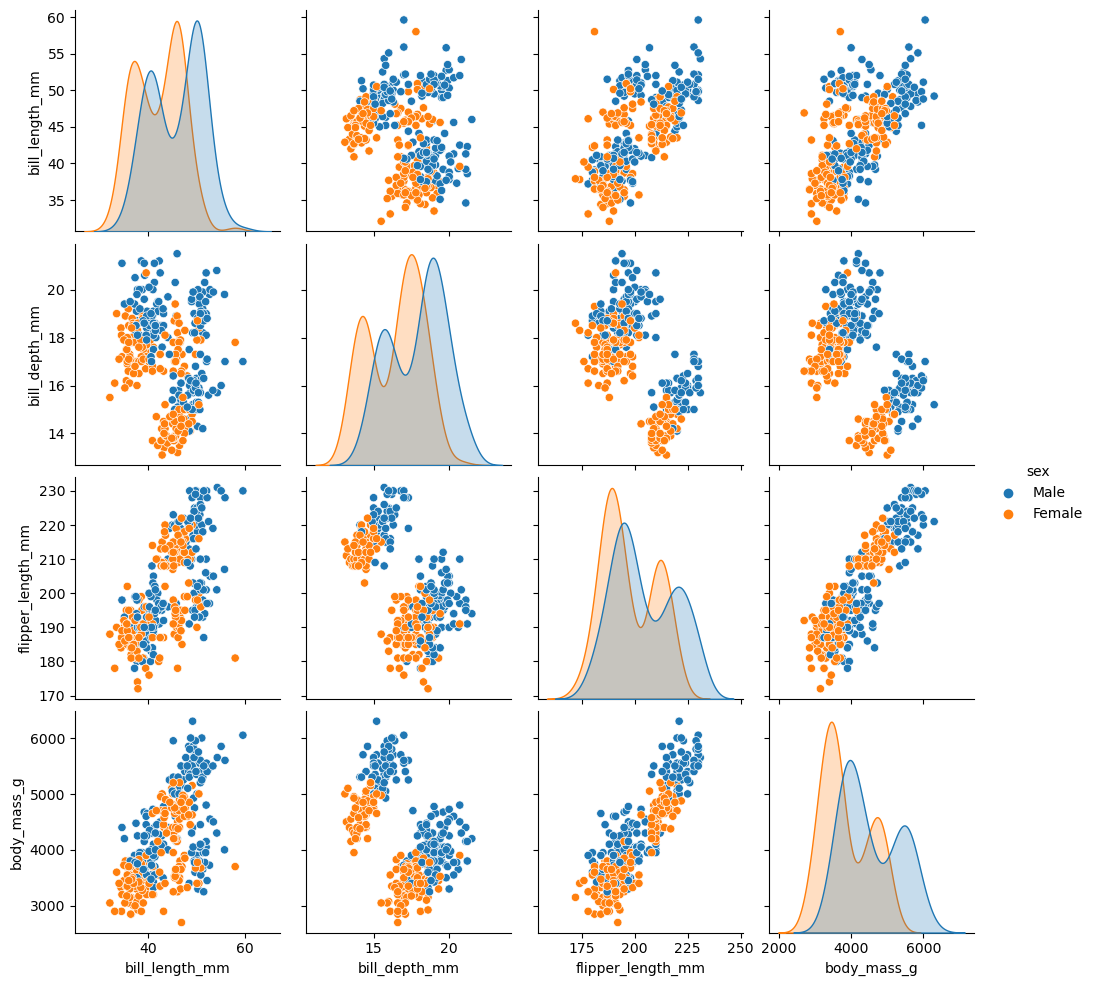

In [5]:
# STUDENT ANSWER
# TODO: Generate the pairplot
sns.pairplot(df, hue="sex")
plt.show()

### 2.2 Question 2: Marginal Distributions

*Requires: Cell 2.1*

Observe the diagonal KDE plots in your pairplot. Which of the following best describes the marginal distributions for the continuous features within a single class (e.g., just looking at the female distribution for bill length)?

* a) They are perfectly uniform distributions.
* b) They exhibit bimodal or multimodal characteristics, indicating hidden sub-populations (species).
* c) They are standard univariate normal distributions.

Assign your chosen letter as a string to the variable `s1_q2_ans`.

In [6]:
# STUDENT ANSWER
s1_q2_ans = 'b'

# DO NOT MODIFY BELOW
assert s1_q2_ans == "b", "s1_q2 Public Test Case Failed: Incorrect answer"
print("s1_q2 Public Test Case Passed")

s1_q2 Public Test Case Passed


### 2.3 Question 3: The Independence Assumption

*Requires: Cell 2.1*

Observe the off-diagonal scatter plots (e.g., flipper length vs. body mass). Does the Naïve Bayes conditional independence assumption hold true for this dataset?

* a) Yes, because the points are randomly scattered with zero correlation.
* b) Yes, because the features are conditionally independent given the class.
* c) No, because there are strong, visible linear correlations between several features within the same class.

Assign your chosen letter as a string to the variable `s1_q3_ans`.

In [7]:
# STUDENT ANSWER
s1_q3_ans = 'c'

# DO NOT MODIFY BELOW
assert s1_q3_ans in ["a", "b", "c"], "s1_q3 Public Test Case Failed: Invalid value"
print("s1_q3 Public Test Case Passed")

s1_q3 Public Test Case Passed


---

## 3. Section 2: Learning the Gaussian Mixture Classifier

Because the continuous features you visualised in Section 1 often have two distinct peaks (bimodal), fitting a single Gaussian (normal) distribution to them will result in a poor model. The mean would simply land in the valley between the two peaks.

To model this accurately, we will use a **Gaussian Mixture Model (GMM)**. A GMM assumes that the data is generated by a mixture of several Gaussian distributions. In our case, we will assume two components per feature.

### 3.1 Question 1: Class Priors

*Requires: Cell 2.0.1*

Compute the prior probability of each class based on the training data `y_train`.
Assign your numpy array containing $P(Female)$ and $P(Male)$ to the variable `s2_q1_ans`.

In [8]:
# STUDENT ANSWER
s2_q1_ans = np.bincount(y_train) / len(y_train)

# DO NOT MODIFY BELOW
EXPECTED_PRIORS = [0.489, 0.511]
np.testing.assert_allclose(s2_q1_ans, EXPECTED_PRIORS, atol=1e-3, err_msg="s2_q1 Public Test Case Failed: Priors are incorrect")
print("s2_q1 Public Test Case Passed")

s2_q1 Public Test Case Passed


### 3.2 Question 2: GMM Parameter Estimation

*Requires: Cell 2.0.1*

Fitting a GMM analytically typically requires an iterative algorithm such as Expectation-Maximisation. To keep this lab tractable, we will use a deterministic heuristic to partition our data into two components for each feature and class.

**The Heuristic Method:**
For each class $c$ and each feature $f$:

1. Find the median value of the training data for that specific class and feature.
2. Split the data: values $\leq$ median belong to **Component 1**, and values $>$ median belong to **Component 2**.
3. Calculate the maximum likelihood estimates for the mean and variance of both components. Given a set of values $x$ of size $n$, use the MLE formulas from your lectures:
* Mean:

$$\hat{\mu}=\frac{\sum_{i=1}^{n}x_{i}}{n}$$


* Variance:

$$\hat{\sigma}^2=\frac{\sum_{i=1}^{n}(x_{i}-\hat{\mu})^2}{n}$$




4. Calculate the mixing weights ($w_1$, $w_2$) for the components, defined as the proportion of data points in each component relative to the total number of points for that class and feature ($w_1=n_1/n_{total}$).

**Data Structure:**
Store your computed parameters in the three pre-defined numpy arrays: `s2_q2_means`, `s2_q2_vars`, and `s2_q2_weights`. Each array has a shape of `(2, 4, 2)`. The axes represent:

* **Axis 0 (Class Index):** `0` = Female, `1` = Male.
* **Axis 1 (Feature Index):** `0` = `bill_length_mm`, `1` = `bill_depth_mm`, `2` = `flipper_length_mm`, `3` = `body_mass_g`.
* **Axis 2 (Component Index):** `0` = Component 1, `1` = Component 2.

*Note: If a component has variance 0 (which occurs if all points in a split are identical), set its variance to 1e-6 to prevent numerical instability.*

In [9]:
s2_q2_means = np.zeros((2, 4, 2))
s2_q2_vars = np.zeros((2, 4, 2))
s2_q2_weights = np.zeros((2, 4, 2))

# STUDENT ANSWER
# TODO
for c in range(2):
    Xc = X_train[y_train == c]

    for f in range(4):
        vals = Xc[:, f]

        median = np.median(vals)

        comp1 = vals[vals <= median]
        comp2 = vals[vals > median]

        s2_q2_means[c, f, 0] = np.mean(comp1)
        s2_q2_means[c, f, 1] = np.mean(comp2)

        s2_q2_vars[c, f, 0] = np.var(comp1)
        s2_q2_vars[c, f, 1] = np.var(comp2)

        s2_q2_weights[c, f, 0] = len(comp1) / len(vals)
        s2_q2_weights[c, f, 1] = len(comp2) / len(vals)

# DO NOT MODIFY BELOW
assert s2_q2_means.shape == (2, 4, 2), "s2_q2 Public Test Case Failed: Incorrect means shape"
assert s2_q2_vars.shape == (2, 4, 2), "s2_q2 Public Test Case Failed: Incorrect vars shape"
assert s2_q2_weights.shape == (2, 4, 2), "s2_q2 Public Test Case Failed: Incorrect weights shape"
assert np.allclose(np.sum(s2_q2_weights, axis=2), 1.0), "s2_q2 Public Test Case Failed: Weights must sum to 1 across components"

EXPECTED_MEAN_SUM = 17841.514
np.testing.assert_allclose(np.sum(s2_q2_means), EXPECTED_MEAN_SUM, atol=1.0, err_msg="s2_q2 Public Test Case Failed: Computed means are incorrect")
print("s2_q2 Public Test Case Passed")

s2_q2 Public Test Case Passed


### 3.3 Question 3: GMM Class Conditional Function

*Requires: Cell 3.2*

Implement the function `s2_class_conditional_fn` to compute $P(x|c)$ for a single feature. The probability density function of our 2-component GMM is the weighted sum of the two individual Gaussians:


$$P(x|c)=w_1\mathcal{N}(x|\mu_1,\sigma_1^2)+w_2\mathcal{N}(x|\mu_2,\sigma_2^2)$$

Recall the standard 1D Gaussian probability density function from your lectures:


$$p(x|\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

In [10]:
# STUDENT ANSWER
def s2_class_conditional_fn(x_val, class_idx, feature_idx, means, vars_, weights):

    prob = 0

    for k in range(2):
        mu = means[class_idx, feature_idx, k]
        var = vars_[class_idx, feature_idx, k]
        w = weights[class_idx, feature_idx, k]

        gaussian = (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x_val - mu)**2 / (2 * var))

        prob += w * gaussian

    return prob

# DO NOT MODIFY BELOW
test_prob = s2_class_conditional_fn(X_train[0, 0], 0, 0, s2_q2_means, s2_q2_vars, s2_q2_weights)
EXPECTED_PROB = 0.0668
np.testing.assert_allclose(test_prob, EXPECTED_PROB, atol=1e-2, err_msg="s2_q3 Public Test Case Failed: Incorrect probability returned")
print("s2_q3 Public Test Case Passed")

s2_q3 Public Test Case Passed


---

## 4. Section 3: Inference & Underflow Prevention

### 4.1 Question 1: Underflow Prevention

*Requires: Cell 3.3*

When working with continuous features, why is it necessary to compute the log-posterior rather than the standard posterior probability?

* a) Multiplying many small probability density values together can result in numerical underflow, causing the computer to round the result to zero.
* b) Taking the log prevents the zero-frequency problem if a feature value was not seen in training.
* c) Logarithms automatically normalise the data to standard distributions.

Assign your chosen letter as a string to the variable `s3_q1_ans`.

In [11]:
# STUDENT ANSWER
s3_q1_ans = "a"

# DO NOT MODIFY BELOW
assert s3_q1_ans in ["a", "b", "c"], "s3_q1 Public Test Case Failed: Invalid value"
print("s3_q1 Public Test Case Passed")

s3_q1 Public Test Case Passed


### 4.2 Question 2: Log-Posterior Calculation

*Requires: Cells 3.1, 3.2, 3.3, and 4.1*

Write a function `s3_log_posterior` that calculates the unnormalised log-posterior probability for a single penguin across all 4 features.
Formula:


$$\log(P(c|x))\propto\log(P(c))+\sum_{i=1}^n\log(P(x_i|c))$$

In [12]:
# STUDENT ANSWER
def s3_log_posterior(x_vec, class_idx, priors, means, vars_, weights):

    log_prob = np.log(priors[class_idx])

    for f in range(4):
        cond_prob = s2_class_conditional_fn(x_vec[f], class_idx, f, means, vars_, weights)
        log_prob += np.log(cond_prob)

    return log_prob

# DO NOT MODIFY BELOW
test_lp = s3_log_posterior(X_test[0], 0, s2_q1_ans, s2_q2_means, s2_q2_vars, s2_q2_weights)
EXPECTED_LP = -17.612
np.testing.assert_allclose(test_lp, EXPECTED_LP, atol=1e-1, err_msg="s3_q2 Public Test Case Failed: Incorrect log-posterior returned")
print("s3_q2 Public Test Case Passed")

s3_q2 Public Test Case Passed


---

## 5. Section 4: Model Evaluation

### 5.1 Question 1: Test Set Predictions

*Requires: Cell 4.2*

Generate predictions for the entire `X_test` dataset. Compare the log-posterior for Female (0) and Male (1) and select the class with the highest value. In the event of a tie, default to 0.

Assign your 1D integer array of predictions to `s4_q1_ans`.

In [13]:
# STUDENT ANSWER
s4_q1_ans = np.zeros(len(X_test), dtype=int)
for i, x_vec in enumerate(X_test):
    lp0 = s3_log_posterior(x_vec, 0, s2_q1_ans, s2_q2_means, s2_q2_vars, s2_q2_weights)
    lp1 = s3_log_posterior(x_vec, 1, s2_q1_ans, s2_q2_means, s2_q2_vars, s2_q2_weights)
    s4_q1_ans[i] = 1 if lp1 > lp0 else 0

# DO NOT MODIFY BELOW
assert s4_q1_ans.shape == (len(X_test),), "s4_q1 Public Test Case Failed: Incorrect shape"
EXPECTED_PREDICTIONS_SUM = 29
assert np.sum(s4_q1_ans) == EXPECTED_PREDICTIONS_SUM, "s4_q1 Public Test Case Failed: Incorrect predictions"
print("s4_q1 Public Test Case Passed")

s4_q1 Public Test Case Passed


### 5.2 Question 2: Accuracy

*Requires: Cell 5.1*

Compute the overall accuracy of the model on the test set. Assign your calculated float value to `s4_q2_ans`.

In [14]:
# STUDENT ANSWER
s4_q2_ans = np.sum(s4_q1_ans == y_test) / len(y_test)

# DO NOT MODIFY BELOW
EXPECTED_ACCURACY = 0.896
np.testing.assert_allclose(s4_q2_ans, EXPECTED_ACCURACY, atol=1e-3, err_msg="s4_q2 Public Test Case Failed: Incorrect accuracy")
print("s4_q2 Public Test Case Passed")

s4_q2 Public Test Case Passed


### 5.3 Question 3: Final Reflection

*Requires: Cell 5.2*

Reflect on your results. In Section 1, you visually proved that the features were highly correlated, meaning the core conditional independence assumption of Naïve Bayes failed entirely. Despite this, how does the model typically perform?

* a) It performs very poorly, proving that Naïve Bayes should never be used on correlated data.
* b) It achieves strong accuracy, demonstrating that Naïve Bayes is often robust and practically effective even when its core assumptions are violated.
* c) It perfectly separates the classes because Gaussian Mixture Models completely cancel out feature correlation.

Assign your chosen letter as a string to the variable `s4_q3_ans`.

In [15]:
# STUDENT ANSWER
s4_q3_ans = "b"

# DO NOT MODIFY BELOW
assert s4_q3_ans in ["a", "b", "c"], "s4_q3 Public Test Case Failed: Invalid value"
print("s4_q3 Public Test Case Passed")

s4_q3 Public Test Case Passed


# END